In [32]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import numpy as np

In [10]:
data_train = pd.read_csv('data/conjunto_de_treinamento.csv')
data_test = pd.read_csv('data/conjunto_de_teste.csv')

data_train.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,...,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,...,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,...,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,...,0,1,0,0,0,0,0,0,0,350000.0


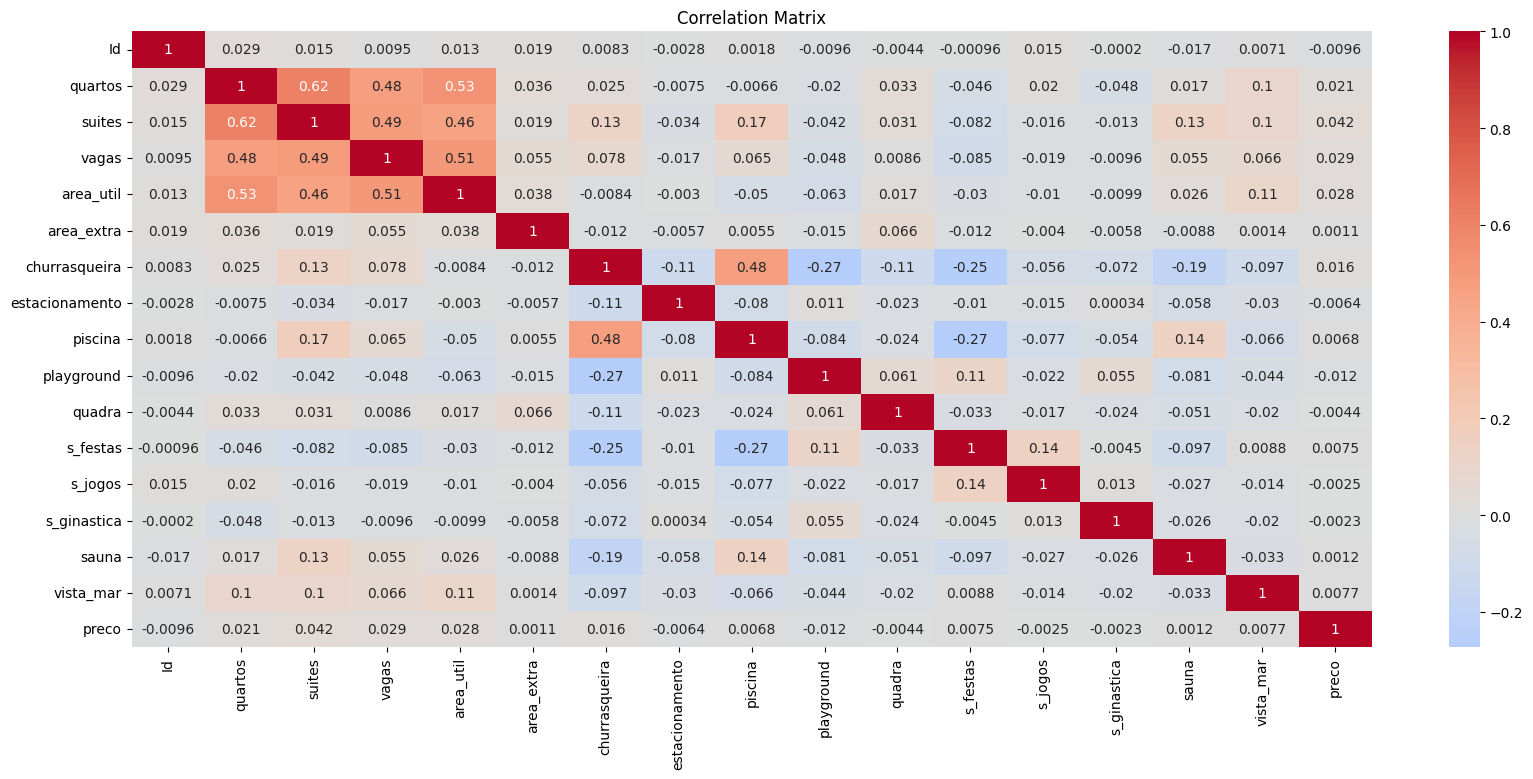

In [25]:
# Extract numerical columns
numerical_df = data_train.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
numeric_features = ['quartos', 'vagas', 'area_util', 'area_extra']
categorical_features = ['tipo', 'bairro', 'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra', 's_festas',
                         's_jogos', 's_ginastica', 'sauna', 'vista_mar']

In [31]:
# Função para calcular RMSPE


def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

# Função para treinar e avaliar modelos
def evaluate_models(models, X_train, y_train):
    scorer = make_scorer(rmspe, greater_is_better=False)
    results = {}
    for name, model in models.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', model)])
        scores = cross_val_score(pipeline, X_train, y_train, scoring=scorer, cv=5)
        results[name] = np.mean(scores)
    return results


# Separamos os recursos e o alvo
X = data_train.drop('preco', axis=1)
y = data_train['preco']

# Dividimos os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos a pré-processamento para variáveis numéricas e categóricas
numeric_features = ['quartos', 'vagas', 'area_util', 'area_extra']
categorical_features = ['tipo', 'bairro', 'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra', 's_festas',
                         's_jogos', 's_ginastica', 'sauna', 'vista_mar']
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combinamos os pré-processadores em um ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Modelos a serem avaliados
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RandomForest': RandomForestRegressor()
}

# Avaliar os modelos
results = evaluate_models(models, X_train, y_train)
for model_name, score in results.items():
    print(f'{model_name}: RMSPE = {-score}')

# Treinar o melhor modelo nos dados completos
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]

# Pipeline com o melhor modelo
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', best_model)])

pipeline.fit(X_train, y_train)

# Fazemos previsões no conjunto de teste de treino
y_pred = pipeline.predict(X_test)

# Avaliamos o modelo
print(f'RMSPE no conjunto de teste: {rmspe(y_test, y_pred)}')

# Leitura do conjunto de teste
df_test = pd.read_csv('data/conjunto_de_teste.csv')

# Separamos o ID para o resultado final
ids = df_test['Id']

# Removemos a coluna id para prever
X_test_final = df_test.drop('Id', axis=1)

# Fazemos previsões no conjunto de teste
preco_pred = pipeline.predict(X_test_final)

# Criamos um DataFrame com os resultados
result = pd.DataFrame({'Id': ids, 'preco': preco_pred})

# Salvamos o resultado em um arquivo CSV
result.to_csv('previsoes_preco.csv', index=False)

d:\UFRJ\9º Período\Intro a ML\eel891-machine-learning-intro\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.3077088862536954e+17, tolerance: 51598390699270.94
  model = cd_fast.sparse_enet_coordinate_descent(
d:\UFRJ\9º Período\Intro a ML\eel891-machine-learning-intro\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.7345513492204714e+17, tolerance: 40115706021247.07
  model = cd_fast.sparse_enet_coordinate_descent(
d:\UFRJ\9º Período\Intro a ML\eel891-machine-learning-intro\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.2995297528346e+17, tolerance: 51603791245818.8
  model

LinearRegression: RMSPE = 4.699489484669821
Ridge: RMSPE = 4.95243612867233
Lasso: RMSPE = 4.711034049702303
RandomForest: RMSPE = 16.174818887820333
RMSPE no conjunto de teste: 7.595201123593127


d:\UFRJ\9º Período\Intro a ML\eel891-machine-learning-intro\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.2838791065935114e+17, tolerance: 51640219742085.586
  model = cd_fast.sparse_enet_coordinate_descent(


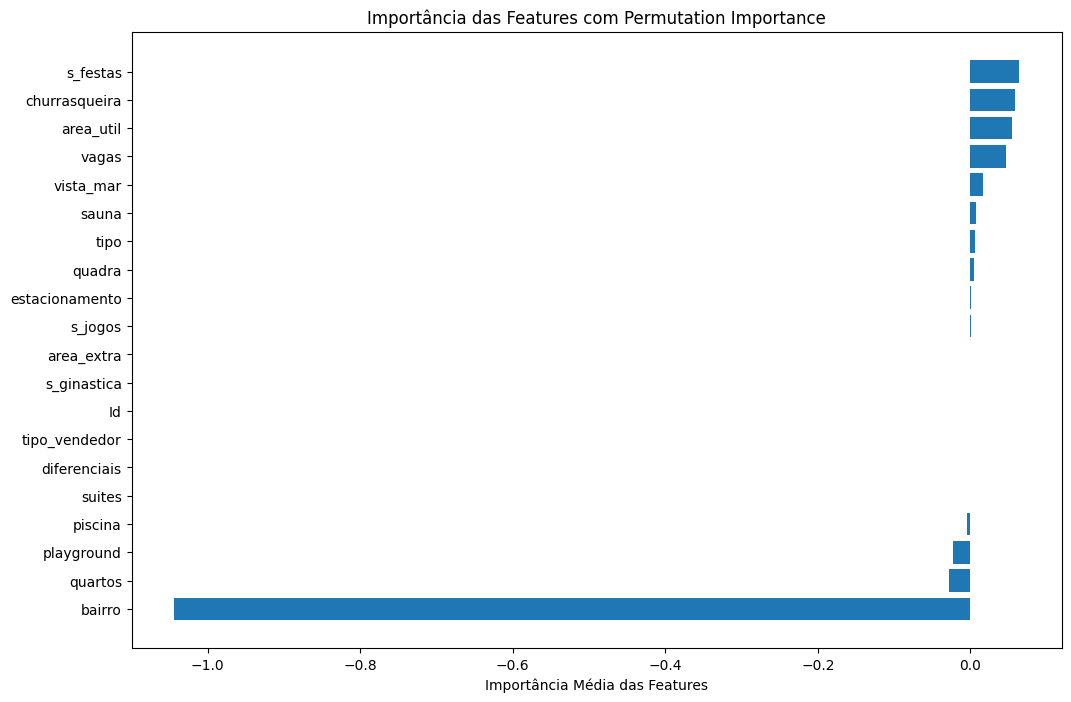

In [41]:

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', models['Lasso'])])

pipeline.fit(X_train, y_train)

result = permutation_importance(pipeline, X_test, y_test, scoring=make_scorer(rmspe, greater_is_better=False))
sorted_idx = result.importances_mean.argsort()

# Plotar a importância das features
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.xlabel('Importância Média das Features')
plt.title('Importância das Features com Permutation Importance')
plt.show()